# RFM Test
## With google AI Studio and colab
- 繪製Elbow Chart，幫助判斷執行 K-means 的最佳分組數
- 執行k-maans分群，群數為4
- R、F、M欄位繪製 "成對散布圖 Pair Plot"，並以 Cluster 標籤分組


In [9]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [10]:
df=pd.read_csv("RFM_raw data.csv")
df.head

<bound method NDFrame.head of           Date     InvoNo CustomerKey     Amount
0     20180402  AP1803827       A1067   836.0000
1     20180403  AP1808235       A1129   836.0000
2     20180404  AP1807305       A1133   836.0000
3     20180405  AP1806145       A0464   836.0000
4     20180405  AP1803092       A0383   836.0000
...        ...        ...         ...        ...
9376  20190102  JA1905084       A0922  2472.7020
9377  20190102  JA1908815       A0738  3500.7984
9378  20190104  JA1903532       A0632  2365.4400
9379  20190104  JA1902149       A1036  6020.8400
9380  20190104  JA1907784       A1057   205.7000

[9381 rows x 4 columns]>

In [11]:

# -------------------------------------------------------------
# 步驟 1：重新讀取原始檔案（請換成你的真實路徑或檔案名稱）
# -------------------------------------------------------------

df = pd.read_csv("RFM_raw data.csv")     # 如果是 csv

# -------------------------------------------------------------
# 步驟 2：正確解析 YYYYMMDD 純數字日期
# -------------------------------------------------------------
# 關鍵：先轉成純整數字串（去掉可能的小數點 .0），再用 %Y%m%d 解析
df['Date'] = df['Date'].astype(str).str.split('.').str[0].str.strip()
df['Date'] = pd.to_datetime(df['Date'], format='%Y%m%d')

# 檢查一下全表最大日期，此時「必須」顯示 2019-01-04
max_date = df['Date'].max()
print("【正確解析後的全表最大日期】:", max_date)

# -------------------------------------------------------------
# 步驟 3：清理客戶編號格式（去掉空白）
# -------------------------------------------------------------
df['CustomerKey'] = df['CustomerKey'].astype(str).str.strip()

# -------------------------------------------------------------
# 步驟 4：分組計算 RFM
# -------------------------------------------------------------
result = df.groupby('CustomerKey').agg(
    F=('InvoNo', 'nunique'),
    M=('Amount', 'sum'),
    last_date=('Date', 'max')
).reset_index()

# 計算 R（天數差）
result['R'] = (max_date - result['last_date']).dt.days

# 欄位重新命名與排序
result = result.rename(columns={'CustomerKey': 'customer'})
result = result[['customer', 'F', 'M', 'R']]

# -------------------------------------------------------------
# 步驟 5：驗證 A0350 的結果
# -------------------------------------------------------------

print(result)

【正確解析後的全表最大日期】: 2019-01-04 00:00:00
    customer   F            M   R
0      A0350  25  51238.11440   9
1      A0351   6  17890.31200  16
2      A0352  14  46424.03852  14
3      A0353  14  27607.68636  24
4      A0354   6   9973.92064  31
..       ...  ..          ...  ..
727    A1413  23  52738.79456  10
728    A1415  20  53019.49664  17
729    A1416  24  49938.38378   4
730    A1419  22  64257.84520  50
731    A1420  14  25054.18342  85

[732 rows x 4 columns]


In [12]:
from sklearn.preprocessing import MinMaxScaler

# 複製一份資料進行正規化處理
nrfm = result.copy()

# 初始化 MinMaxScaler
scaler = MinMaxScaler()

# 對 R, F, M 進行正規化
nrfm[['F', 'M', 'R']] = scaler.fit_transform(nrfm[['F', 'M', 'R']])

# 顯示前幾筆結果
nrfm.head()

,customer,F,M,R
0,A0350,0.631579,0.376563,0.024523
1,A0351,0.131579,0.127866,0.043597
2,A0352,0.342105,0.340662,0.038147
3,A0353,0.342105,0.200335,0.065395
4,A0354,0.131579,0.068827,0.084469


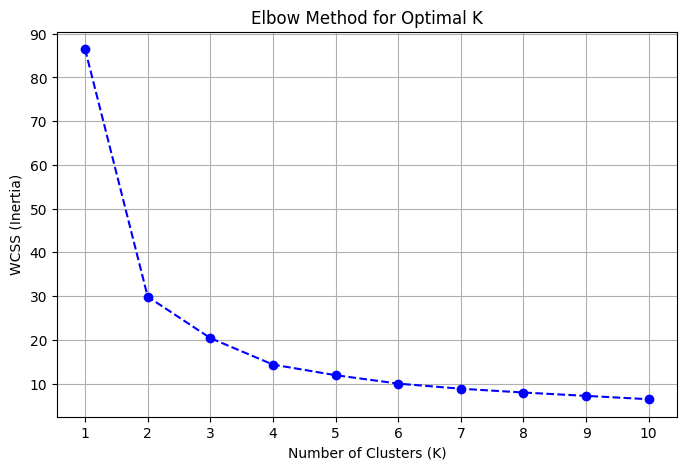

In [23]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

# 提取用於分群的特徵欄位（F, M, R）
features = nrfm[['F', 'M', 'R']]

wcss = []
k_range = range(1, 11)

# 計算每個 K 值的 WCSS
for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(features)
    wcss.append(kmeans.inertia_)

# 繪製手肘法圖表
plt.figure(figsize=(8, 5))
plt.plot(k_range, wcss, marker='o', linestyle='--', color='b')
plt.title('Elbow Method for Optimal K')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('WCSS (Inertia)')
plt.xticks(k_range)
plt.grid(True)
plt.show()

In [24]:
from sklearn.cluster import KMeans

# 設定群數為 4
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)

# 進行分群預測（使用已經正規化的特徵）
cluster_labels = kmeans.fit_predict(nrfm[['F', 'M', 'R']])

# 將分群結果加入原始的 result 與 正規化後的 nrfm
result['Cluster'] = cluster_labels
nrfm['Cluster'] = cluster_labels

# 顯示各群的資料數量
print("各群組（Cluster）的客戶數量分布：")
print(result['Cluster'].value_counts().sort_index())

# 顯示前 5 筆結果
result.head()

各群組（Cluster）的客戶數量分布：
Cluster
0     76
1    221
2    321
3    114
Name: count, dtype: int64


,customer,F,M,R,Cluster,Group
0,A0350,25,51238.11440,9,1,High
1,A0351,6,17890.31200,16,2,Low
2,A0352,14,46424.03852,14,1,High
3,A0353,14,27607.68636,24,1,High
4,A0354,6,9973.92064,31,2,Low


In [25]:
# 顯示含有分群標籤的原始 result 資料前 10 筆，確認標籤已正確貼回
display(result.head(10))

,customer,F,M,R,Cluster,Group
0,A0350,25,51238.11440,9,1,High
1,A0351,6,17890.31200,16,2,Low
2,A0352,14,46424.03852,14,1,High
3,A0353,14,27607.68636,24,1,High
4,A0354,6,9973.92064,31,2,Low
5,A0355,8,20105.90008,29,2,Low
6,A0356,10,15733.79076,85,2,Low
7,A0357,20,58583.10320,24,1,High
8,A0363,4,8215.54050,8,2,Low
9,A0365,5,13192.47600,92,2,Low


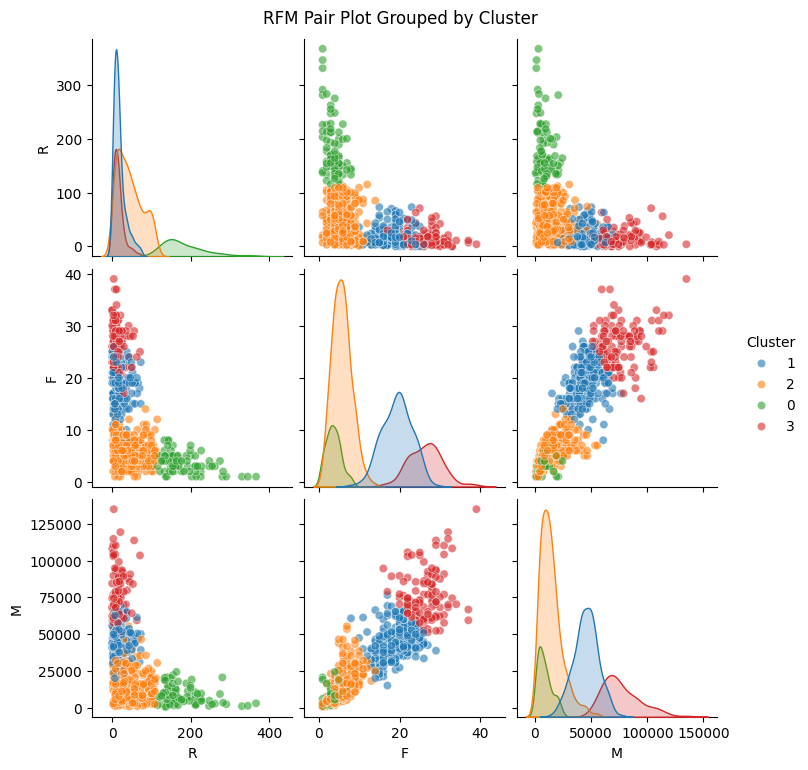

In [26]:
import seaborn as sns
import matplotlib.pyplot as plt

# 使用 seaborn 繪製 Pair Plot，並用 Cluster 欄位做為 hue (顏色分類)
# 將 Cluster 轉為 category 或是字串型態，使圖例呈現離散的群組分類顏色
plot_df = result.copy()
plot_df['Cluster'] = plot_df['Cluster'].astype(str)

sns.pairplot(plot_df, vars=['R', 'F', 'M'], hue='Cluster', palette='tab10', diag_kind='kde', plot_kws={'alpha': 0.6})
plt.suptitle('RFM Pair Plot Grouped by Cluster', y=1.02)
plt.show()

In [36]:
# 定義 Cluster 到 Group 的對應關係
group_mapping = {
    0: 'Missing',
    1: 'High',
    2: 'Low',
    3: 'VIP'
}

# 新增 Group 欄位
result['Group'] = result['Cluster'].map(group_mapping)

# 顯示前 10 筆結果以供確認
display(result.head(10))

,customer,F,M,R,Cluster,Group
0,A0350,25,51238.11440,9,1,High
1,A0351,6,17890.31200,16,2,Low
2,A0352,14,46424.03852,14,1,High
3,A0353,14,27607.68636,24,1,High
4,A0354,6,9973.92064,31,2,Low
5,A0355,8,20105.90008,29,2,Low
6,A0356,10,15733.79076,85,2,Low
7,A0357,20,58583.10320,24,1,High
8,A0363,4,8215.54050,8,2,Low
9,A0365,5,13192.47600,92,2,Low


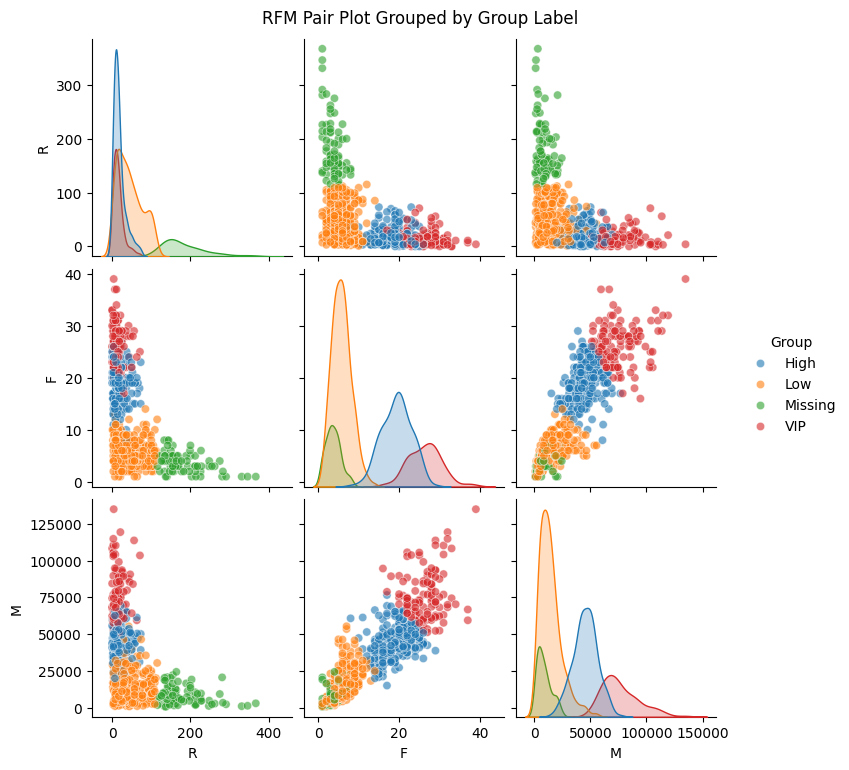

In [37]:
import seaborn as sns
import matplotlib.pyplot as plt

# 使用 seaborn 繪製 Pair Plot，並用剛剛新增的 'Group' 欄位作為 hue (顏色分類)
sns.pairplot(result, vars=['R', 'F', 'M'], hue='Group', palette='tab10', diag_kind='kde', plot_kws={'alpha': 0.6})
plt.suptitle('RFM Pair Plot Grouped by Group Label', y=1.02)
plt.show()

In [39]:
import seaborn as sns
import matplotlib.pyplot as plt
from google.colab import files

# 重新繪製 Pair Plot
g = sns.pairplot(result, vars=['R', 'F', 'M'], hue='Group', palette='tab10', diag_kind='kde', plot_kws={'alpha': 0.6})
g.fig.suptitle('RFM Pair Plot Grouped by Group Label', y=1.02)

# 將圖片儲存為透明背景的 PNG 檔
file_name = 'RFM_Pairplot.png'
plt.savefig(file_name, dpi=300, transparent=True, bbox_inches='tight')
plt.close()

# 觸發下載檔案
files.download(file_name)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [30]:
from google.colab import files

# 將 result 儲存為 CSV 檔案，不包含索引值 (index)
csv_file_name = 'RFM_result.csv'
result.to_csv(csv_file_name, index=False)

# 觸發下載檔案
files.download(csv_file_name)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [35]:
result.groupby('Cluster')[['R', 'F', 'M']].mean()

,R,F,M
Cluster,,,
0,182.723684,3.657895,8569.692582
1,17.710407,19.316742,45267.863586
2,44.479751,5.694704,14127.145096
3,15.315789,26.368421,76632.327280
